# Exercice 1
### Import et affichage des 5 premières lignes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams["figure.figsize"] = (11, 6)

games = pd.read_csv("../../data/flipper_games.csv")

games.head()

,timestamp,player_id,machine_id,machine_type,arcade_zone,game_mode,game_duration_s,pause_s,tilt_risk_pct,ball_speed_mps,playfield_temp_c,error_code,game_status,incident_label
0,2026-02-03 10:00:00,P001,F17,electromechanical,C3,speedrun,188,0,39.32,1.154,37.76,NaN,completed,0
1,2026-02-03 10:00:00,P221,F04,solid_state,D1,multiball,218,23,76.10,1.002,30.84,NaN,completed,0
2,2026-02-03 10:05:00,P034,F13,digital,C1,classic,143,21,5.86,0.965,33.96,NaN,completed,0
3,2026-02-03 10:05:00,P007,F06,solid_state,D1,multiball,319,41,47.16,1.054,28.43,NaN,completed,0
4,2026-02-03 10:05:00,P009,F16,electromechanical,A2,classic,175,33,60.06,0.934,22.61,NaN,completed,0


### Affichage des types des colonnes

In [2]:
games.info()

<class 'pandas.DataFrame'>
RangeIndex: 5409 entries, 0 to 5408
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   timestamp         5409 non-null   str    
 1   player_id         5409 non-null   str    
 2   machine_id        5409 non-null   str    
 3   machine_type      5409 non-null   str    
 4   arcade_zone       5409 non-null   str    
 5   game_mode         5409 non-null   str    
 6   game_duration_s   5409 non-null   int64  
 7   pause_s           5409 non-null   int64  
 8   tilt_risk_pct     5409 non-null   float64
 9   ball_speed_mps    5409 non-null   float64
 10  playfield_temp_c  5409 non-null   float64
 11  error_code        279 non-null    str    
 12  game_status       5409 non-null   str    
 13  incident_label    5409 non-null   int64  
dtypes: float64(3), int64(3), str(8)
memory usage: 591.7 KB


### Affichage du nombre de lignes et de colonnes (Ainsi que du nombre de joueurs uniques)

In [3]:
number_of_unique_player = games["player_id"].nunique()
lignes = games.shape[0]
colonnes = games.shape[1]

print("le dataset contient", lignes, "lignes,", colonnes, "colonnes et", number_of_unique_player, "joueurs")

le dataset contient 5409 lignes, 14 colonnes et 260 joueurs


# Exercice 2

### Suppression des doublons : 

In [4]:
games_clean = games.drop_duplicates()
games_clean

,timestamp,player_id,machine_id,machine_type,arcade_zone,game_mode,game_duration_s,pause_s,tilt_risk_pct,ball_speed_mps,playfield_temp_c,error_code,game_status,incident_label
0,2026-02-03 10:00:00,P001,F17,electromechanical,C3,speedrun,188,0,39.32,1.154,37.76,NaN,completed,0
1,2026-02-03 10:00:00,P221,F04,solid_state,D1,multiball,218,23,76.10,1.002,30.84,NaN,completed,0
2,2026-02-03 10:05:00,P034,F13,digital,C1,classic,143,21,5.86,0.965,33.96,NaN,completed,0
3,2026-02-03 10:05:00,P007,F06,solid_state,D1,multiball,319,41,47.16,1.054,28.43,NaN,completed,0
4,2026-02-03 10:05:00,P009,F16,electromechanical,A2,classic,175,33,60.06,0.934,22.61,NaN,completed,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5404,2026-02-12 21:20:00,P077,F11,digital,D1,classic,166,40,61.93,1.376,30.34,NaN,completed,0
5405,2026-02-12 21:25:00,P180,F15,electromechanical,C2,speedrun,168,21,66.50,1.109,31.17,NaN,completed,0
5406,2026-02-12 21:25:00,P228,F03,solid_state,A2,multiball,310,1,64.41,1.124,28.49,NaN,completed,0
5407,2026-02-12 21:25:00,P213,F01,solid_state,C3,speedrun,168,29,22.25,0.810,25.05,NaN,completed,0


### Conservation des parties avec game_duration_s

In [5]:
games_clean = games_clean[games_clean["game_duration_s"] > 0]
games_clean

,timestamp,player_id,machine_id,machine_type,arcade_zone,game_mode,game_duration_s,pause_s,tilt_risk_pct,ball_speed_mps,playfield_temp_c,error_code,game_status,incident_label
0,2026-02-03 10:00:00,P001,F17,electromechanical,C3,speedrun,188,0,39.32,1.154,37.76,NaN,completed,0
1,2026-02-03 10:00:00,P221,F04,solid_state,D1,multiball,218,23,76.10,1.002,30.84,NaN,completed,0
2,2026-02-03 10:05:00,P034,F13,digital,C1,classic,143,21,5.86,0.965,33.96,NaN,completed,0
3,2026-02-03 10:05:00,P007,F06,solid_state,D1,multiball,319,41,47.16,1.054,28.43,NaN,completed,0
4,2026-02-03 10:05:00,P009,F16,electromechanical,A2,classic,175,33,60.06,0.934,22.61,NaN,completed,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5403,2026-02-12 21:20:00,P196,F20,electromechanical,C3,multiball,392,33,29.62,1.604,36.07,NaN,completed,0
5404,2026-02-12 21:20:00,P077,F11,digital,D1,classic,166,40,61.93,1.376,30.34,NaN,completed,0
5405,2026-02-12 21:25:00,P180,F15,electromechanical,C2,speedrun,168,21,66.50,1.109,31.17,NaN,completed,0
5406,2026-02-12 21:25:00,P228,F03,solid_state,A2,multiball,310,1,64.41,1.124,28.49,NaN,completed,0


### Conservation des lignes avec tilt_risk_pct entre 0 et 100

In [6]:
games_clean = games_clean[games_clean["tilt_risk_pct"].between(0, 100)]
games_clean

,timestamp,player_id,machine_id,machine_type,arcade_zone,game_mode,game_duration_s,pause_s,tilt_risk_pct,ball_speed_mps,playfield_temp_c,error_code,game_status,incident_label
0,2026-02-03 10:00:00,P001,F17,electromechanical,C3,speedrun,188,0,39.32,1.154,37.76,NaN,completed,0
1,2026-02-03 10:00:00,P221,F04,solid_state,D1,multiball,218,23,76.10,1.002,30.84,NaN,completed,0
2,2026-02-03 10:05:00,P034,F13,digital,C1,classic,143,21,5.86,0.965,33.96,NaN,completed,0
3,2026-02-03 10:05:00,P007,F06,solid_state,D1,multiball,319,41,47.16,1.054,28.43,NaN,completed,0
4,2026-02-03 10:05:00,P009,F16,electromechanical,A2,classic,175,33,60.06,0.934,22.61,NaN,completed,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5403,2026-02-12 21:20:00,P196,F20,electromechanical,C3,multiball,392,33,29.62,1.604,36.07,NaN,completed,0
5404,2026-02-12 21:20:00,P077,F11,digital,D1,classic,166,40,61.93,1.376,30.34,NaN,completed,0
5405,2026-02-12 21:25:00,P180,F15,electromechanical,C2,speedrun,168,21,66.50,1.109,31.17,NaN,completed,0
5406,2026-02-12 21:25:00,P228,F03,solid_state,A2,multiball,310,1,64.41,1.124,28.49,NaN,completed,0


### Conservation des lignes avec pause_s >= 0

In [7]:
games_clean = games_clean[games_clean["pause_s"] >= 0]
games_clean

,timestamp,player_id,machine_id,machine_type,arcade_zone,game_mode,game_duration_s,pause_s,tilt_risk_pct,ball_speed_mps,playfield_temp_c,error_code,game_status,incident_label
0,2026-02-03 10:00:00,P001,F17,electromechanical,C3,speedrun,188,0,39.32,1.154,37.76,NaN,completed,0
1,2026-02-03 10:00:00,P221,F04,solid_state,D1,multiball,218,23,76.10,1.002,30.84,NaN,completed,0
2,2026-02-03 10:05:00,P034,F13,digital,C1,classic,143,21,5.86,0.965,33.96,NaN,completed,0
3,2026-02-03 10:05:00,P007,F06,solid_state,D1,multiball,319,41,47.16,1.054,28.43,NaN,completed,0
4,2026-02-03 10:05:00,P009,F16,electromechanical,A2,classic,175,33,60.06,0.934,22.61,NaN,completed,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5403,2026-02-12 21:20:00,P196,F20,electromechanical,C3,multiball,392,33,29.62,1.604,36.07,NaN,completed,0
5404,2026-02-12 21:20:00,P077,F11,digital,D1,classic,166,40,61.93,1.376,30.34,NaN,completed,0
5405,2026-02-12 21:25:00,P180,F15,electromechanical,C2,speedrun,168,21,66.50,1.109,31.17,NaN,completed,0
5406,2026-02-12 21:25:00,P228,F03,solid_state,A2,multiball,310,1,64.41,1.124,28.49,NaN,completed,0


### Bilan sur le nombre de lignes retirées : 

In [8]:
before = games.shape[0]
after = games_clean.shape[0]
print("Avant : ", before, "lignes")
print("Après :", after, "lignes")
print("Nombre de lignes retirées : ", (before - after))

Avant :  5409 lignes
Après : 5354 lignes
Nombre de lignes retirées :  55


# Exercice 3
### Création de la colonne binaire is_error

In [9]:
games_clean["is_error"] = np.where(games_clean["game_status"] == "failed", 1, 0)
games_clean.head()

,timestamp,player_id,machine_id,machine_type,arcade_zone,game_mode,game_duration_s,pause_s,tilt_risk_pct,ball_speed_mps,playfield_temp_c,error_code,game_status,incident_label,is_error
0,2026-02-03 10:00:00,P001,F17,electromechanical,C3,speedrun,188,0,39.32,1.154,37.76,NaN,completed,0,0
1,2026-02-03 10:00:00,P221,F04,solid_state,D1,multiball,218,23,76.10,1.002,30.84,NaN,completed,0,0
2,2026-02-03 10:05:00,P034,F13,digital,C1,classic,143,21,5.86,0.965,33.96,NaN,completed,0,0
3,2026-02-03 10:05:00,P007,F06,solid_state,D1,multiball,319,41,47.16,1.054,28.43,NaN,completed,0,0
4,2026-02-03 10:05:00,P009,F16,electromechanical,A2,classic,175,33,60.06,0.934,22.61,NaN,completed,0,0


### Calcule par zone d'arcade à travers un tableau : 

In [10]:
zone_kpi = games_clean.groupby("arcade_zone").agg(
    nb_parties = ("arcade_zone", "count"),
    nb_unique_player = ("player_id", "nunique"),
    error_rate = ("is_error", "mean"),
    average_pause = ("pause_s", "mean")
).sort_values("error_rate", ascending=False)

zone_kpi

,nb_parties,nb_unique_player,error_rate,average_pause
arcade_zone,,,,
C2,668,243,0.062874,18.485030
C3,686,241,0.059767,26.115160
B2,627,242,0.057416,17.496013
D1,674,244,0.051929,19.017804
A2,640,238,0.046875,18.081250
A1,650,238,0.046154,18.006154
B1,700,248,0.045714,17.844286
C1,709,243,0.045134,18.535966


### 2 observations métiers rapides : 

- Les zones C2 et C3 sont les zones les plus risquées en terme d'erreurs (environs 6 %)

- La zone C3 combine fort taux de pause ainsi qu'un taux d'erreur parmis les plus élevés (26 secondes)

# Exercice 4 à ajouter ici : [TODO]

# Exercice 5

### Graphique avec outliers visible :

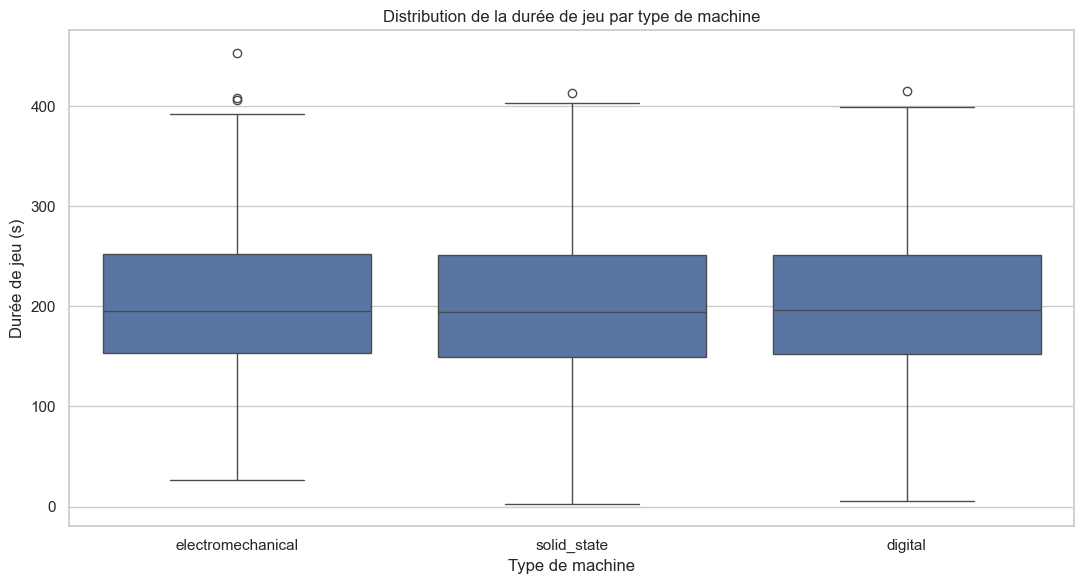

In [11]:
games_clean = games.drop_duplicates()
games_clean = games_clean[games_clean["game_duration_s"] > 0]
games_clean = games_clean[games_clean["tilt_risk_pct"].between(0, 100)]
games_clean = games_clean[games_clean["pause_s"] >= 0]

sns.boxplot(data=games_clean, x="machine_type", y="game_duration_s")
plt.title("Distribution de la durée de jeu par type de machine")
plt.xlabel("Type de machine")
plt.ylabel("Durée de jeu (s)")
plt.tight_layout()
plt.show()

### Graphique sans outliers visible

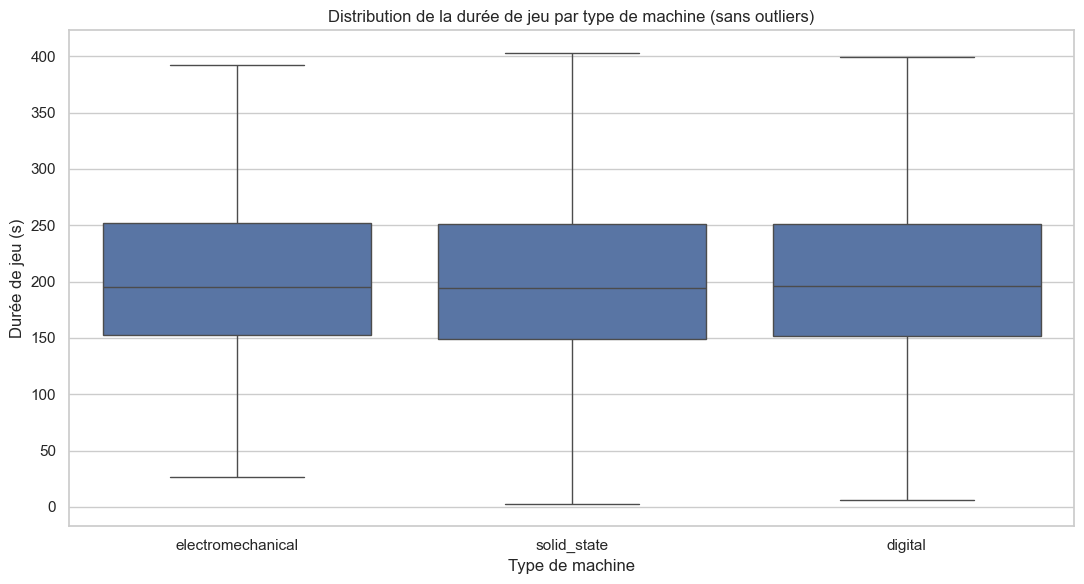

In [12]:
sns.boxplot(data=games_clean, x="machine_type", y="game_duration_s", showfliers=False)
plt.title("Distribution de la durée de jeu par type de machine (sans outliers)")
plt.xlabel("Type de machine")
plt.ylabel("Durée de jeu (s)")
plt.tight_layout()
plt.show()

### Voici les 3 conclusions :

1- Le type de machine ne change pas vraiment le temps de jeu moyen (Durée d'une partie similaire pour les trois types de machines).

2- Les comportements des joueurs sont globalement comparables quel que soit le type de machine (La variation des durées de jeu est proche entre les types, même si electromechanical semble légèrement moins dispersé (moustache plus courte vers le bas)).

3- On peut observer encore quelques valeurs extrêmes élevées.